# Ir Alem 2 -- Diagnostico Visual em Cardiologia com Rede Neural

**Objetivo:** Classificar imagens de eletrocardiogramas (ECG) como **normal** ou **anormal** utilizando uma Rede Neural Artificial do tipo MLP (Perceptron Multicamadas) com Keras.

**Dataset:** 928 imagens de ECG de pacientes cardiacos (Mendeley Data), organizadas em 4 classes originais e agrupadas em classificacao binaria.

---

## 1. Imports e Configuracoes

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import tensorflow as tf

# Sementes para reproducibilidade
np.random.seed(42)
tf.random.set_seed(42)

print('Imports carregados com sucesso.')

  warnings.warn(


Imports carregados com sucesso.


In [2]:
# Caminho base para as imagens de ECG
BASE_PATH = os.path.join('..', 'docs', 'imagens', 'ecg', 'train')

# Mapeamento: 4 classes originais -> 2 classes binarias
# 0 = Normal | 1 = Anormal
CLASSES_MAP = {
    'normal': 0,
    'batimento card\u00edaco anormal': 1,
    'infarto do mioc\u00e1rdio': 1,
    'hist\u00f3rico de infarto do mioc\u00e1rdio': 1
}

LABELS = {0: 'Normal', 1: 'Anormal'}

# Dimensao para redimensionamento
# 64x64 = 4.096 features (melhor relacao features/amostras que 128x128)
IMG_SIZE = 64

print(f'Caminho base: {os.path.abspath(BASE_PATH)}')
print(f'Dimensao alvo: {IMG_SIZE}x{IMG_SIZE} pixels (escala de cinza)')
print(f'Total de features apos flatten: {IMG_SIZE * IMG_SIZE}')

Caminho base: ../docs/imagens/ecg/train
Dimensao alvo: 64x64 pixels (escala de cinza)
Total de features apos flatten: 4096


---
## 2. Carregamento dos Dados

Percorremos as 4 pastas de imagens e atribuimos o label binario (0 = Normal, 1 = Anormal).

In [3]:
imagens = []
labels = []

for pasta, label in CLASSES_MAP.items():
    caminho_pasta = os.path.join(BASE_PATH, pasta)
    
    if not os.path.exists(caminho_pasta):
        print(f'AVISO: Pasta nao encontrada: {caminho_pasta}')
        continue
    
    arquivos = [f for f in os.listdir(caminho_pasta) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for arquivo in arquivos:
        caminho_img = os.path.join(caminho_pasta, arquivo)
        img = cv2.imread(caminho_img)
        if img is not None:
            imagens.append(img)
            labels.append(label)
    
    print(f'  [{LABELS[label]}] {pasta}: {len(arquivos)} imagens')

print(f'\nTotal de imagens carregadas: {len(imagens)}')

  [Normal] normal: 284 imagens


  [Anormal] batimento cardíaco anormal: 233 imagens


  [Anormal] infarto do miocárdio: 239 imagens


  [Anormal] histórico de infarto do miocárdio: 172 imagens

Total de imagens carregadas: 928


---
## 3. Exploracao dos Dados

Normal:  284 imagens (30.6%)
Anormal: 644 imagens (69.4%)


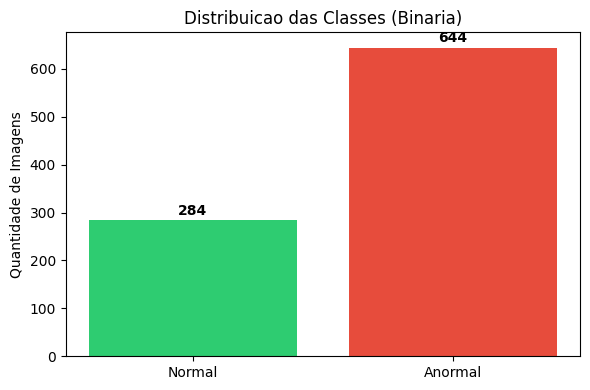

In [4]:
labels_array = np.array(labels)
contagem_normal = np.sum(labels_array == 0)
contagem_anormal = np.sum(labels_array == 1)

print(f'Normal:  {contagem_normal} imagens ({contagem_normal/len(labels)*100:.1f}%)')
print(f'Anormal: {contagem_anormal} imagens ({contagem_anormal/len(labels)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Normal', 'Anormal'], [contagem_normal, contagem_anormal], 
              color=['#2ecc71', '#e74c3c'])
ax.set_ylabel('Quantidade de Imagens')
ax.set_title('Distribuicao das Classes (Binaria)')
for bar, count in zip(bars, [contagem_normal, contagem_anormal]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

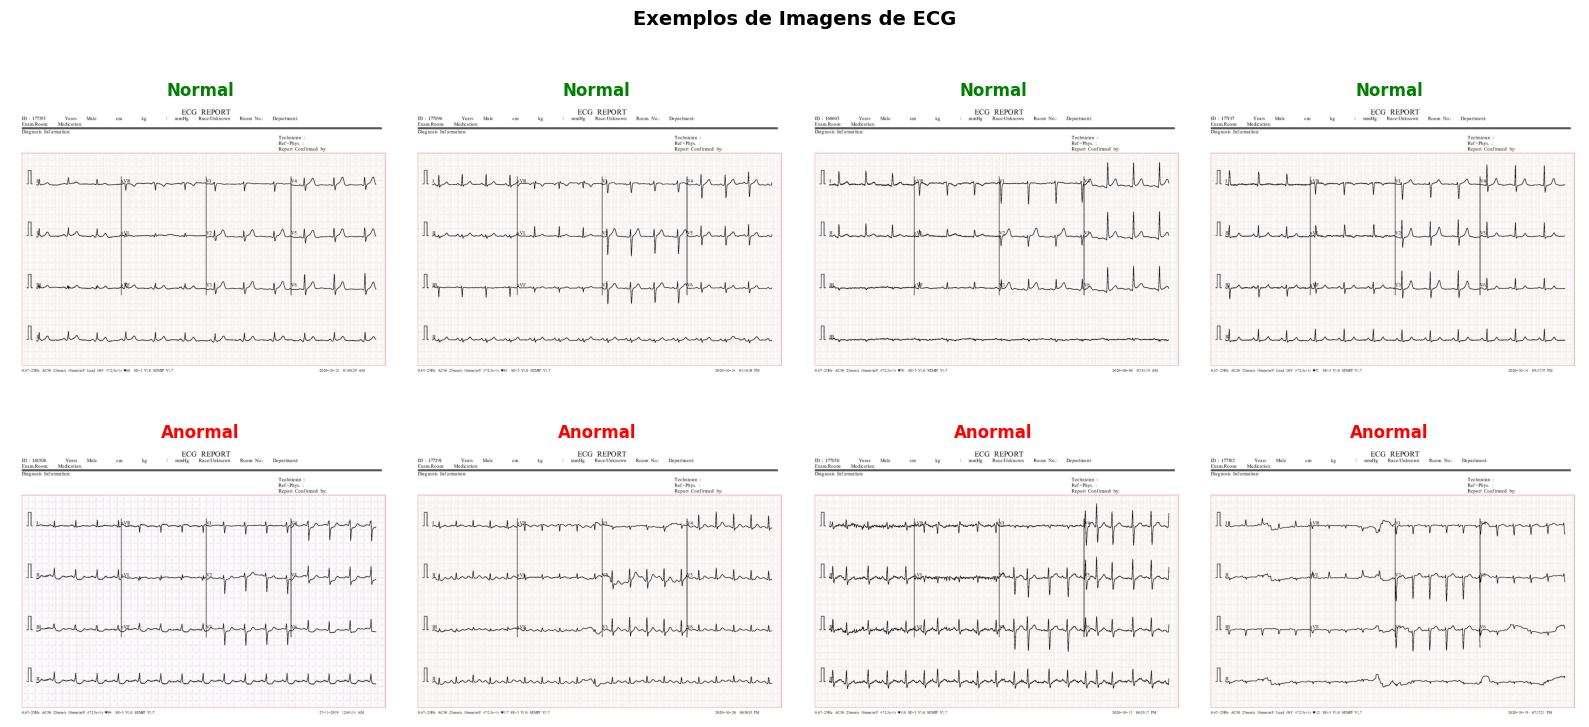

Dimensao original: (1572, 2213, 3)
Tipo de dado: uint8


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Exemplos de Imagens de ECG', fontsize=14, fontweight='bold')

idx_normal = [i for i, l in enumerate(labels) if l == 0]
idx_anormal = [i for i, l in enumerate(labels) if l == 1]

for i in range(4):
    img_rgb = cv2.cvtColor(imagens[idx_normal[i]], cv2.COLOR_BGR2RGB)
    axes[0][i].imshow(img_rgb)
    axes[0][i].set_title('Normal', color='green', fontweight='bold')
    axes[0][i].axis('off')

for i in range(4):
    img_rgb = cv2.cvtColor(imagens[idx_anormal[i]], cv2.COLOR_BGR2RGB)
    axes[1][i].imshow(img_rgb)
    axes[1][i].set_title('Anormal', color='red', fontweight='bold')
    axes[1][i].axis('off')

plt.tight_layout()
plt.show()

print(f'Dimensao original: {imagens[0].shape}')
print(f'Tipo de dado: {imagens[0].dtype}')

---
## 4. Pre-processamento das Imagens

1. **Converter para escala de cinza** (a informacao do ECG esta na forma da onda, nao nas cores)
2. **Redimensionar** para 64x64 pixels
3. **Achatar (flatten)** em vetor de 4.096 posicoes
4. **Normalizar** pixels de [0, 255] para [0, 1]

In [6]:
imagens_processadas = []

for img in imagens:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))
    img_flat = img_resized.flatten()
    imagens_processadas.append(img_flat)

X = np.array(imagens_processadas, dtype=np.float32)
y = np.array(labels)

X = X / 255.0

print(f'Shape de X (features): {X.shape}')
print(f'Shape de y (labels):   {y.shape}')
print(f'Cada imagem = vetor de {X.shape[1]} features')
print(f'Pixels normalizados: [{X.min():.2f}, {X.max():.2f}]')

Shape de X (features): (928, 4096)
Shape de y (labels):   (928,)
Cada imagem = vetor de 4096 features
Pixels normalizados: [0.00, 1.00]


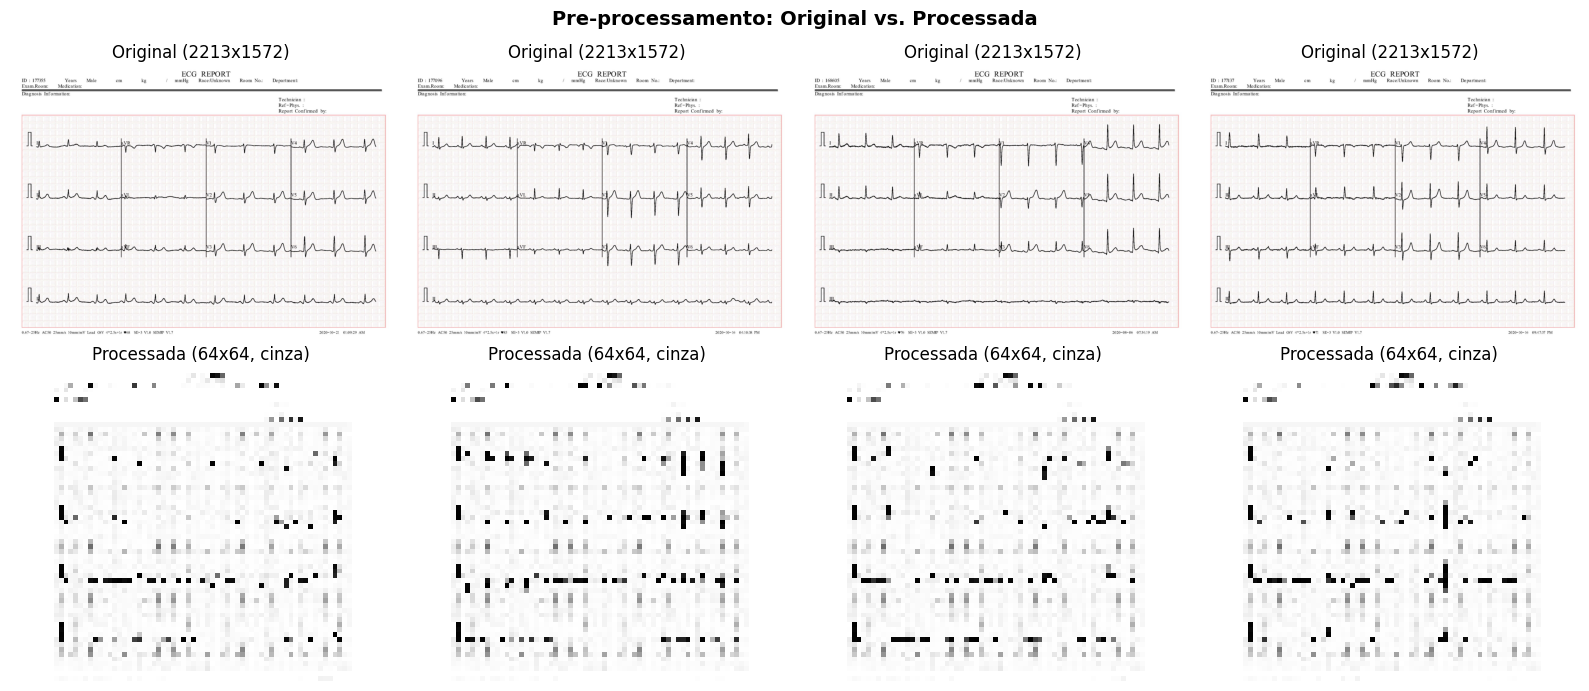

In [7]:
# Visualizacao: original vs. processada
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Pre-processamento: Original vs. Processada', fontsize=14, fontweight='bold')

for i in range(4):
    img_rgb = cv2.cvtColor(imagens[i], cv2.COLOR_BGR2RGB)
    axes[0][i].imshow(img_rgb)
    axes[0][i].set_title(f'Original ({imagens[i].shape[1]}x{imagens[i].shape[0]})')
    axes[0][i].axis('off')
    
    img_processed = X[i].reshape(IMG_SIZE, IMG_SIZE)
    axes[1][i].imshow(img_processed, cmap='gray')
    axes[1][i].set_title(f'Processada ({IMG_SIZE}x{IMG_SIZE}, cinza)')
    axes[1][i].axis('off')

plt.tight_layout()
plt.show()

---
## 5. Divisao Treino / Teste

80% treino / 20% teste, com estratificacao.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras (Normal: {np.sum(y_train == 0)}, Anormal: {np.sum(y_train == 1)})')
print(f'Teste:  {X_test.shape[0]} amostras (Normal: {np.sum(y_test == 0)}, Anormal: {np.sum(y_test == 1)})')

Treino: 742 amostras (Normal: 227, Anormal: 515)
Teste:  186 amostras (Normal: 57, Anormal: 129)


---
## 6. Tratamento do Desbalanceamento

O dataset possui ~30% Normal vs ~70% Anormal. Usamos **class_weight** para penalizar mais os erros na classe minoritaria.

In [9]:
classes = np.unique(y_train)
pesos = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {0: pesos[0] * 1.5, 1: pesos[1]}

print(f'Pesos das classes (ajustados):')
print(f'  Normal (0):  {class_weight[0]:.4f}')
print(f'  Anormal (1): {class_weight[1]:.4f}')
print(f'  Razao: {class_weight[0]/class_weight[1]:.1f}x mais peso na classe Normal')

Pesos das classes (ajustados):
  Normal (0):  2.4515
  Anormal (1): 0.7204
  Razao: 3.4x mais peso na classe Normal


---
## 7. Construcao da Rede Neural MLP

Arquitetura compacta para evitar overfitting com dataset pequeno:

```
Input (4.096) -> Dense(256, ReLU) -> BatchNorm -> Dropout(0.3)
             -> Dense(128, ReLU) -> BatchNorm -> Dropout(0.3)
             -> Dense(64, ReLU)  -> Dropout(0.2)
             -> Dense(1, Sigmoid)
```

In [10]:
modelo = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')
])

modelo.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo.summary()

  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,091,585 (4.16 MB)

 Trainable params: 1,090,817 (4.16 MB)

 Non-trainable params: 768 (3.00 KB)

---
## 8. Treinamento

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

historico = modelo.fit(
    X_train, y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1
)

print(f'\nTreinamento finalizado na epoch {len(historico.history["loss"])}')

Epoch 1/150


 1/38 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6875 - loss: 1.2384

27/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6535 - loss: 1.2418

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6455 - loss: 1.2291 - val_accuracy: 0.6980 - val_loss: 0.6112


Epoch 2/150


...

Epoch 44/150


 1/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0014

28/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0093

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0085 - val_accuracy: 0.8523 - val_loss: 0.7114



Treinamento finalizado na epoch 44


---
## 9. Avaliacao do Modelo

In [12]:
loss_teste, acc_teste = modelo.evaluate(X_test, y_test, verbose=0)

print(f'Resultado no conjunto de teste:')
print(f'  Loss:     {loss_teste:.4f}')
print(f'  Acuracia: {acc_teste:.4f} ({acc_teste*100:.2f}%)')

Resultado no conjunto de teste:
  Loss:     0.3555
  Acuracia: 0.8602 (86.02%)


In [13]:
y_pred_prob = modelo.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


### 9.1 Matriz de Confusao

- **Falsos Negativos** (anormal classificado como normal): perigoso em contexto medico
- **Falsos Positivos** (normal classificado como anormal): gera exames adicionais

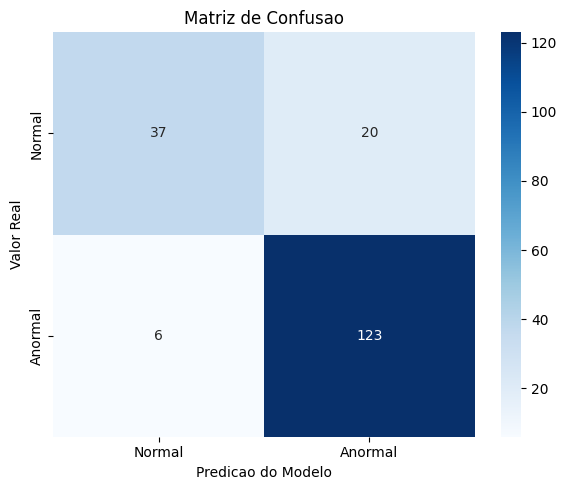

In [14]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anormal'],
            yticklabels=['Normal', 'Anormal'], ax=ax)
ax.set_xlabel('Predicao do Modelo')
ax.set_ylabel('Valor Real')
ax.set_title('Matriz de Confusao')
plt.tight_layout()
plt.show()

### 9.2 Relatorio de Classificacao

- **Precision**: dos que o modelo disse ser X, quantos realmente sao?
- **Recall**: dos que realmente sao X, quantos o modelo identificou?
- **F1-Score**: media harmonica entre precision e recall

In [15]:
print('Relatorio de Classificacao:\n')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anormal']))

Relatorio de Classificacao:

              precision    recall  f1-score   support

      Normal       0.86      0.65      0.74        57
     Anormal       0.86      0.95      0.90       129

    accuracy                           0.86       186
   macro avg       0.86      0.80      0.82       186
weighted avg       0.86      0.86      0.85       186



### 9.3 Curvas de Aprendizado

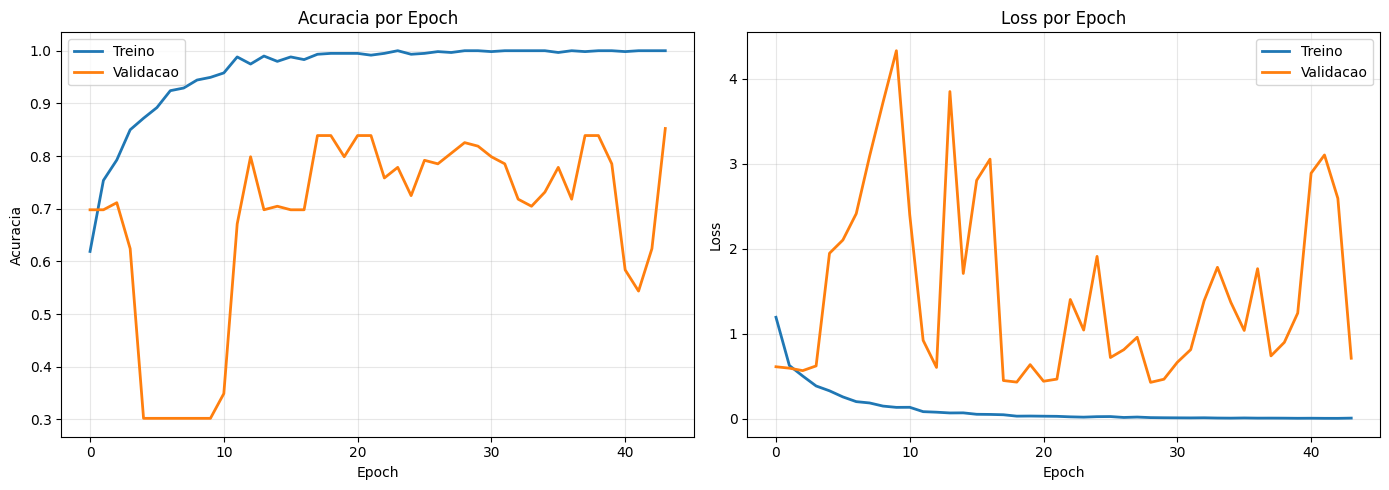

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(historico.history['accuracy'], label='Treino', linewidth=2)
ax1.plot(historico.history['val_accuracy'], label='Validacao', linewidth=2)
ax1.set_title('Acuracia por Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Acuracia')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(historico.history['loss'], label='Treino', linewidth=2)
ax2.plot(historico.history['val_loss'], label='Validacao', linewidth=2)
ax2.set_title('Loss por Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. Conclusao

Neste projeto, construimos um classificador binario de imagens de ECG utilizando uma rede neural MLP (Perceptron Multicamadas) com Keras. O pipeline completo incluiu:

1. **Carregamento** de 928 imagens de ECG de pacientes cardiacos
2. **Agrupamento** das 4 classes originais em classificacao binaria (Normal vs. Anormal)
3. **Pre-processamento**: redimensionamento (64x64), conversao para escala de cinza, achatamento e normalizacao
4. **Tratamento do desbalanceamento** com class_weight ajustado
5. **Construcao** de uma MLP com tres camadas ocultas (256, 128 e 64 neuronios), BatchNormalization e Dropout
6. **Treinamento** com otimizador Adam (lr=0.0003), binary crossentropy e EarlyStopping
7. **Avaliacao** com acuracia, matriz de confusao, classification report e curvas de aprendizado

### Limitacoes e Proximos Passos

- **MLP vs CNN**: a MLP trata cada pixel como feature independente, perdendo informacoes espaciais. Uma CNN seria mais adequada para visao computacional, pois preserva relacoes entre pixels vizinhos.
- **Dataset pequeno**: 928 imagens e um volume reduzido para deep learning. Data augmentation poderia expandir artificialmente o dataset.
- **Desbalanceamento**: utilizamos class_weight para mitigar o vies para a classe majoritaria. Oversampling (SMOTE) poderia complementar.

O projeto demonstra a aplicacao de redes neurais artificiais na classificacao de imagens medicas, reforçando o potencial da IA como ferramenta de apoio ao diagnostico cardiologico.